# Clasification

In [2]:
# import useful libraries
import numpy as np
import matplotlib.pyplot as plt

# import data
from sklearn.datasets import make_classification

# import classifiers
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier as kNN

# Import validation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

/tmp/ipython-input-1944308814.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes[1].scatter(X_train[:, 0], X_train[:, 1], c = 'b', edgecolors = 'k', cmap = 'Paired')
/tmp/ipython-input-1944308814.py:12: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axes[1].scatter(X_test[:, 0], X_test[:, 1], c = 'r', edgecolors = 'k', cmap = 'Paired', marker = 'x')
/tmp/ipython-input-1944308814.py:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes[1].scatter(X_test[:, 0], X_test[:, 1], c = 'r', edgecolors = 'k', cmap = 'Paired', marker = 'x')


(800, 2) (200, 2) (800,) (200,)


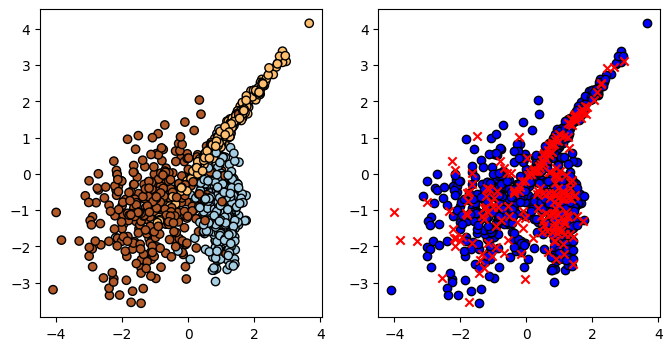

In [7]:
# we create 100 separable points //
X, y = make_classification(n_samples = 1000, n_features = 2, n_classes = 3, n_redundant = 0, n_informative = 2, n_clusters_per_class = 1, random_state = 11)
# Con el valor de uno se calcula el valor del otro test size y train size por cada arreglo de estos devuelve la iteracion de train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

# Plot train / test data
# 1er Plot validacion con Jack Knife
_, axes = plt.subplots (1,2, figsize=(8,4))
axes[0].scatter(X[:, 0], X[:, 1], c = y, edgecolors = 'k', cmap = 'Paired')
#Otro plot con los datos de colores
axes[1].scatter(X_train[:, 0], X_train[:, 1], c = 'b', edgecolors = 'k', cmap = 'Paired')
axes[1].scatter(X_test[:, 0], X_test[:, 1], c = 'r', edgecolors = 'k', cmap = 'Paired', marker = 'x')
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

#Esperaria que mis datos esten bien estratificados


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
'''
    --> Paste your plot_2d_decision_boundaries function here!
'''
%cd /content/drive/MyDrive/content/colab/machine_learning
from Tools.utils import plot_decision_boundary

/content/drive/MyDrive/content/colab/machine_learning


ModuleNotFoundError: No module named 'utils'

AttributeError: 'Figure' object has no attribute 'fit'

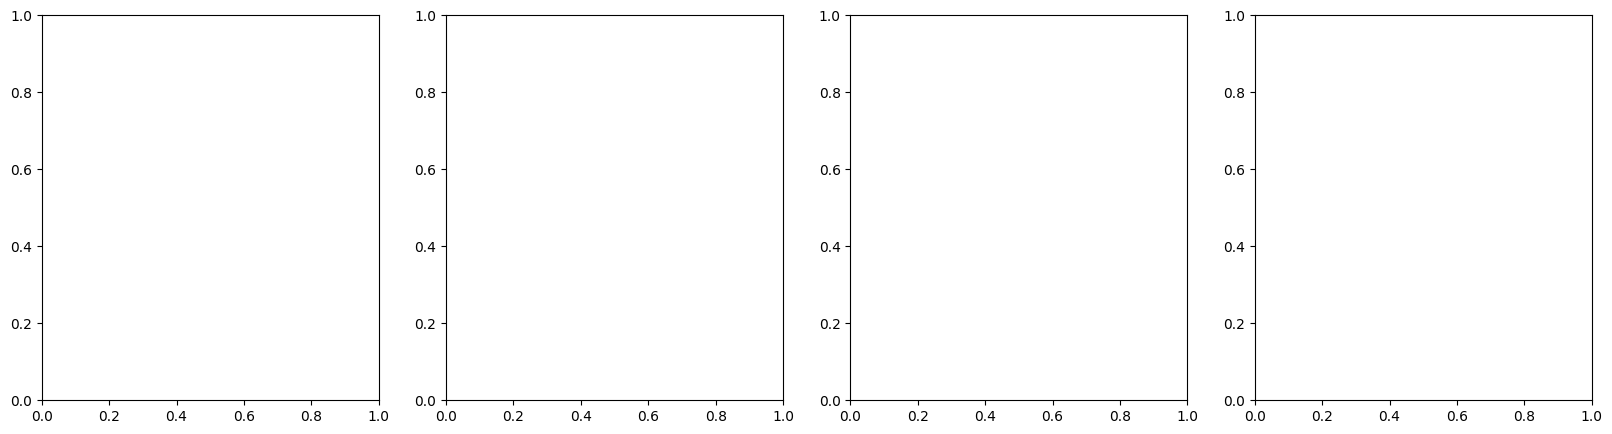

In [16]:
models = [ LogisticRegression() , kNN(n_neighbors= 7 ) , SVC(kernel= 'poly'), SVC(kernel= 'rbf') ]
names = [ 'Logistic Regression' , 'kNN' , 'Poly SVM' , 'RBF SVM' ]

_, axes = plt.subplots(1,len(models), figsize = (5 * len(models),5))
predictions = {} #crear diccionario

# fit the models
for name, model in zip(names, models) :
    #print (name ,model)
    clf = _
    clf.fit( X_train , y_train )

    #Hacer y Guardar predicciones
    #Se va a ser sobre subconjunto de datos de prueba
    predictions[name] = clf.predict(X_test)

    # Plot everything graficar fronteras de decision
    plot_decision_boundary (clf = model, x = X_test, y = y_test, n_points = 100, offset = 0.1, ax = axes)
    axes.set_title(name)
    predictions[name] = clf.predict(X)

plt.show()

In [19]:
predictions['Logistic Regression'].shape

KeyError: 'Logistic Regression'

## Metricas de desempeño

Módulo de [Metrics](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics) de sklearn

In [22]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns #graficas estadisticas (analisis de datos)

########----- Results for Logistic Regression -----########


KeyError: 'Logistic Regression'

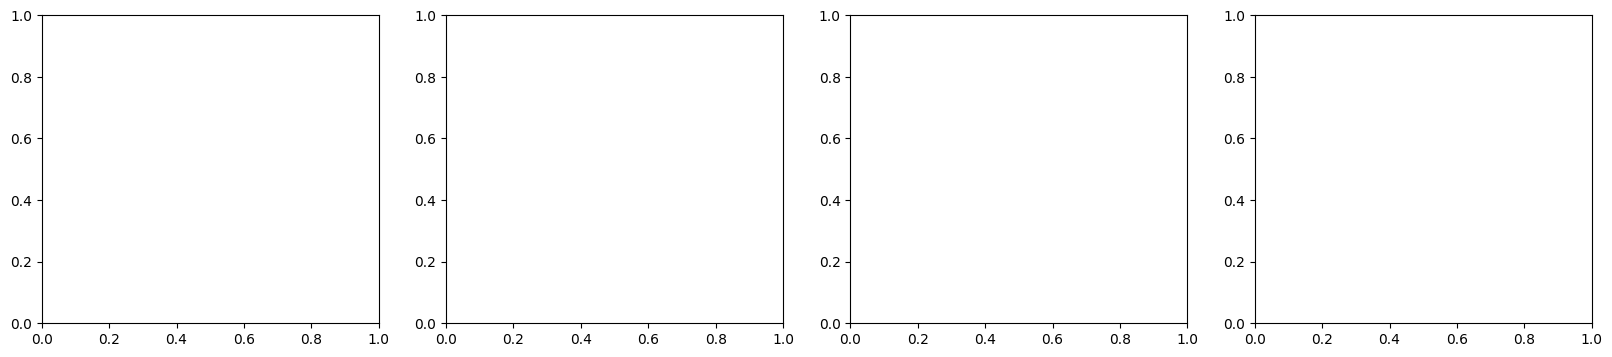

In [26]:
_, axes = plt.subplots(1, len(models), figsize = (len(models)*5, 4))

# Compute metrics - plot confusion matrix
for name, ax in zip(names, axes) :
  print ("########----- Results for {0} -----########".format( name ))
  accuracy = accuracy_score( y_test , predictions[name] ) #pide los valores de mis etiquetas reales primer valor segundo valor predicciones
  precision = precision_score( y_test , predictions[name] , average = "micro") #parametro average micro calcular la prescripcion usando solo los valores de la misma clase y macro usa todas las clases
  recall = recall_score( y_test , predictions[name] , average = "micro")
  f1 = f1_score( y_test , predictions[name] , average = "micro")
  cm = confusion_matrix( y_test , predictions[name] )
  ##--------------
  print("-- Acc --\t -- Prec --\t -- Rec --\t -- F1 --  ")
  print("  {0:.3f}  \t   {1:.3f}  \t   {2:.3f}  \t   {3:.3f}  \t".format(accuracy, precision, recall, f1))
  #print(cm)
  sns.heatmap(cm, cmap = "hot", annot = True, ax = ax )
  axes.set_title( name )

In [53]:
#Cross validation

models = [ LogisticRegression() , kNN(n_neighbors= 7 ) , SVC(kernel= 'poly'), SVC(kernel= 'rbf') ]
names = [ 'Logistic Regression' , 'kNN' , 'Poly SVM' , 'RBF SVM' ]

#_, axes = plt.subplots(1,len(models), figsize = (5 * len(models),5))
predictions = {} #crear diccionario

#creacion de instancia separacion de datos (particiones se llaman splits 5 o 10)
cv = StratifiedKFold(n_splits = 5, shuffle= True, random_state=1)

# fit the models
for name, model in zip(names, models) :
    #print (name ,model)
    #cross_val_score = cross_val_score(model, X_train, y_train, cv = cv)

    #Hacer y Guardar predicciones
    #Se va a ser sobre subconjunto de datos de prueba

    #validacion cruzada manual
    for splits_train, splits_val in cv.split(X_train, y_train):
      X_train_fold = X_train[splits_train]
      y_train_fold = y_train[splits_train]
      X_val_fold = X_train[splits_val]
      y_val_fold = y_train[splits_val]
      model.fit(X_train_fold, y_train_fold)

      model.fit(X_train[splits_train], y_train[splits_train])
      predictions[name] = model.predict(X_train[splits_test])
    print(cross_val_score)

    # Plot everything graficar fronteras de decision
    #plot_decision_boundary (clf = model, x = X_test, y = y_test, n_points = 100, offset = 0.1, ax = axes)
    #axes.set_title(name)
    #predictions[name] = clf.predict(X)

plt.show()

ValueError: Supported target types are: ('binary', 'multiclass'). Got 'continuous' instead.

In [55]:
predictions.keys()
predictions['Poly SRV'].shape

KeyError: 'Poly SRV'

## En datos reales

In [ ]:
# import useful libraries
import numpy as np
import matplotlib.pyplot as plt

# import data
from sklearn.datasets import load_digits

# import classifiers
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier as kNN

(1797, 64)


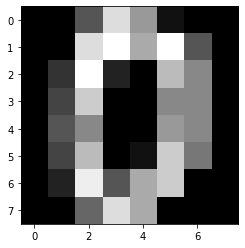

In [ ]:
digits = load_digits()
print(digits.data.shape)

plt.imshow(digits.images[0].reshape(8,8), cmap="gray")

Evalúe los distintos algoritmos entrenando con esta base de datos.

# Regression

In [29]:
# import useful libraries
import numpy as np
import matplotlib.pyplot as plt

# import data
from sklearn.datasets import make_regression

# import classifiers
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

# Import validation
from sklearn.model_selection import train_test_split

/tmp/ipython-input-4106655986.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes[0].scatter(X, y, c='b', edgecolors = 'k', cmap = 'Paired')
/tmp/ipython-input-4106655986.py:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes[1].scatter(X_train, y_train, c='b', edgecolors = 'k', cmap = 'Paired')
/tmp/ipython-input-4106655986.py:13: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axes[1].scatter(X_test, y_test, c='r', edgecolors = 'k', cmap = 'Paired', marker = 'x')
/tmp/ipython-input-4106655986.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes[1].scatter(X_test, y_test, c='r', edgecolors = 'k', cmap = 'Paired', marker = 'x')


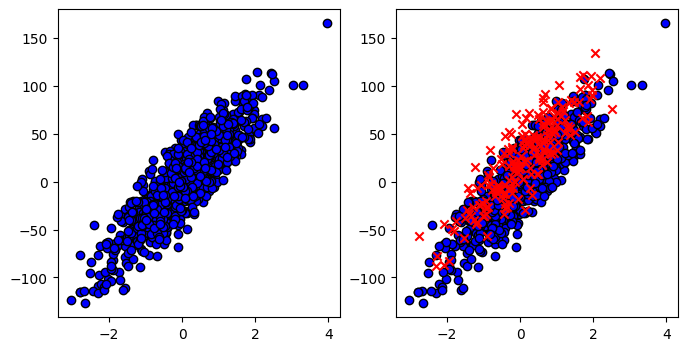

In [38]:
X, y = make_regression(n_samples = 1000, n_features = 1 , noise = 20 , random_state = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)


np.random.seed(0)
y_test = y_test + np.random.normal(len(y_test)) * 0.1

# Plot train / test data
_, axes = plt.subplots(1,2, figsize=(8,4))
axes[0].scatter(X, y, c='b', edgecolors = 'k', cmap = 'Paired')
axes[1].scatter(X_train, y_train, c='b', edgecolors = 'k', cmap = 'Paired')
axes[1].scatter(X_test, y_test, c='r', edgecolors = 'k', cmap = 'Paired', marker = 'x')
#

########----- Results for Linear Regression -----########
########----- Results for Poly SVR -----########
########----- Results for RBF SVR -----########


/tmp/ipython-input-3130418553.py:15: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter (X_test, y_test, c='b', edgecolors = 'k', cmap = 'Paired', marker = 'x')
/tmp/ipython-input-3130418553.py:15: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter (X_test, y_test, c='b', edgecolors = 'k', cmap = 'Paired', marker = 'x')
/tmp/ipython-input-3130418553.py:16: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter (X_test, predictions[name], c='g', edgecolors = 'k', cmap = 'Paired')
/tmp/ipython-input-3130418553.py:15: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter (X_test, y_test, c='b', ed

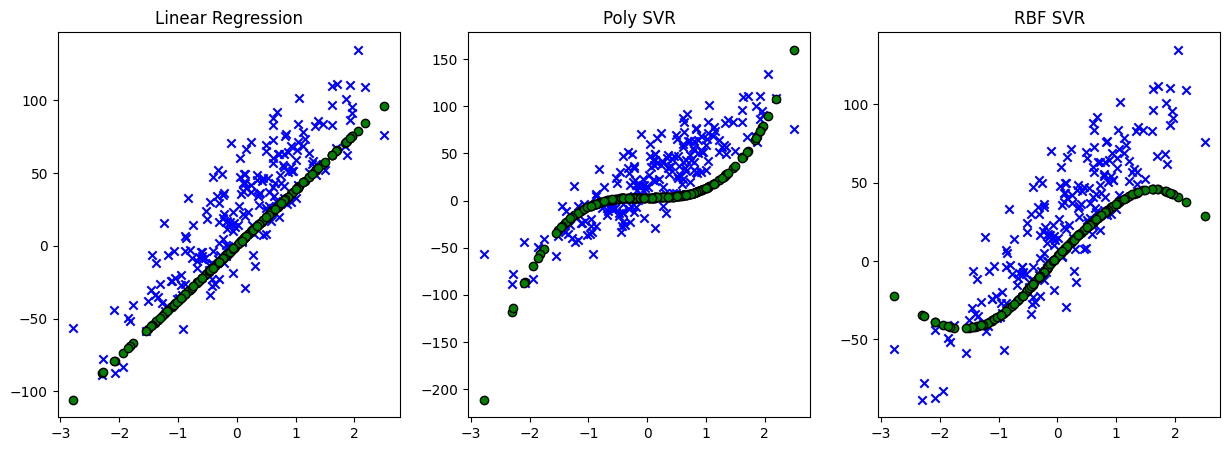

In [44]:
# Train a linear regression

models = [LinearRegression(), SVR(kernel='poly'), SVR(kernel='rbf')]
names = ['Linear Regression', 'Poly SVR', 'RBF SVR']

_, axes = plt.subplots(1,len(models), figsize = (5 * len(models),5))
predictions = {} #crear diccionario

for name, model, ax in zip(names, models, axes) :
    #print (name ,model)
    model.fit( X_train , y_train )
    predictions[name] = model.predict(X_test)
    print("########----- Results for {0} -----########".format( name ))
    #Hacer y Guardar predicciones
    ax.scatter (X_test, y_test, c='b', edgecolors = 'k', cmap = 'Paired', marker = 'x')
    ax.scatter (X_test, predictions[name], c='g', edgecolors = 'k', cmap = 'Paired')
    ax.set_title(name)

plt.show()

## Metricas de desempeño

Módulo de [Metrics](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics) de sklearn

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [45]:
# Compute MAE and MSE
for name in names :
  print ("########----- Results for {0} -----########".format( name ))
  mae_ = mean_absolute_error( y_test , predictions[name] )
  mse_ = mean_squared_error( y_test , predictions[name] )
  print('MAE: {0}'.format(mae_))
  print('MSE: {0}'.format(mse_))
  #Que se el menor numero posible

########----- Results for Linear Regression -----########
MAE: 23.25625727464966
MSE: 829.4392120135906
########----- Results for Poly SVR -----########
MAE: 29.458058446358194
MSE: 1340.6672739653338
########----- Results for RBF SVR -----########
MAE: 24.98730785635249
MSE: 975.877251240215
